In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
# from matplotlib.cm import get_cmap

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [2]:
def import_data(mode:list , num_policy:int , case:str, level:int=5):
    dataset = {key : [] for key in mode}
    for i in dataset.keys():   # sensor modality
        for policy in range(num_policy): # each run have 3 policies
            if case == "slope":
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npz" , allow_pickle=True))

            else:
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npz" , allow_pickle=True))

    # print(dataset)
    for key, value in dataset.items():
        dataset[key] = np.array(value)
    return dataset

In [3]:
NUM_POLICY = 5
# Hebb vs CPG
# mode = ["vel",'pos_action','vel_action','pos_vel_action','vel_imu','pos_action_imu','vel_action_imu',
#  'pos_vel_action_imu','vel_fc','action_fc','vel_action_fc','pos_vel_action_fc','vel_imu_fc',
#  'pos_vel_imu_fc','action_imu_fc','vel_action_imu_fc','pos_vel_action_imu_fc']
mode = ['vel','pos_action','vel_action','pos_vel_action']

flat        =   import_data(mode , NUM_POLICY , case="flat")
slope_10    =   import_data(mode , NUM_POLICY , case="slope",level=-10)
slope10     =   import_data(mode , NUM_POLICY , case="slope",level=10)

mass1000    =   import_data(mode , NUM_POLICY , case="mass" , level=1000)


# flat        =   import_data(mode , NUM_POLICY , case="flat")
rough       =   import_data(mode , NUM_POLICY , case="rough")
morph       =   import_data(mode , NUM_POLICY , case="morph")

slope_list      = [slope10 ,slope_10 ] # The 15 is slip so the result is shown in not significant way. [slope5 , slope10 , slope15 , slope_5 , slope_10 ,  slope_15]
slope_list_str  = ["slope10" , "slope_10"]


mass_list       = [mass1000] # [mass250 , mass500 , mass1000 , mass2000 , mass5000 , mass10000
mass_list_str   = ["mass1000"]
# [case:str][number_file:int][data/brain:str]

In [4]:
def preprocess_combined(selected_dataset, num_pol):
    cases = list(selected_dataset.keys())

    perf_bucket = {case: [] for case in cases}
    dist_bucket = {case: [] for case in cases}
    vel_bucket  = {case: [] for case in cases}

    for policy in range(num_pol):
        for case in cases:
            data = selected_dataset[case][policy]

            reward = np.sum(data["reward"], axis=0)
            perf_bucket[case].append(np.ravel(reward))

            max_pos_x = np.max(data["pos_x"], axis=0)
            dist_bucket[case].append(np.ravel(max_pos_x))

            vel_x = data["vel_b"][:, :, 0]
            avg_vel_x = np.mean(vel_x, axis=0)
            vel_bucket[case].append(np.ravel(avg_vel_x))

    # Concatenate across all policies so each case has one long vector
    performance_all = {"policy": {case: np.concatenate(perf_bucket[case], axis=0) if len(perf_bucket[case]) else np.array([]) for case in cases}}
    max_distance_all = {"policy": {case: np.concatenate(dist_bucket[case], axis=0) if len(dist_bucket[case]) else np.array([]) for case in cases}}
    avg_vel_all = {"policy": {case: np.concatenate(vel_bucket[case], axis=0) if len(vel_bucket[case]) else np.array([]) for case in cases}}

    return performance_all, max_distance_all, avg_vel_all

In [5]:
num_pol = 5
max_distance = {}
reward = {}
avg_vel = {}

# Get performance criteria
# Slope data
for idx , slope_data in enumerate(slope_list):
    reward[slope_list_str[idx]] , max_distance[slope_list_str[idx]] , avg_vel[slope_list_str[idx]]= preprocess_combined(selected_dataset=slope_data , num_pol=num_pol)

# Mass data
for idx , mass_data in enumerate(mass_list):
    reward[mass_list_str[idx]] , max_distance[mass_list_str[idx]] , avg_vel[mass_list_str[idx]]= preprocess_combined(selected_dataset=mass_data , num_pol=num_pol)

reward["flat"] , max_distance["flat"] , avg_vel["flat"] = preprocess_combined(selected_dataset=flat , num_pol=num_pol)
reward["rough"] , max_distance["rough"] , avg_vel["rough"] = preprocess_combined(selected_dataset=rough , num_pol=num_pol)
reward["morph"] , max_distance["morph"] , avg_vel["morph"] = preprocess_combined(selected_dataset=morph , num_pol=num_pol)

In [6]:
sheet3_data = {
    'pos': 0,
    'vel': 5,
    'pos, vel': 0,
    'action': 0,
    'pos, action': 5,
    'vel, action': 5,
    'pos, vel, action': 5,
}

## Training completeness by sensor set (UpSet plot)

Bar height = the dict value (how many of the `NUM_POLICY` runs the policy managed to
learn); the dot matrix below each bar marks which sensors were active for that run.
Bars are sorted ascending and coloured blue when the set is complete (all runs learned),
grey otherwise.

C:\Users\emper\AppData\Local\Temp\ipykernel_15524\2869993698.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


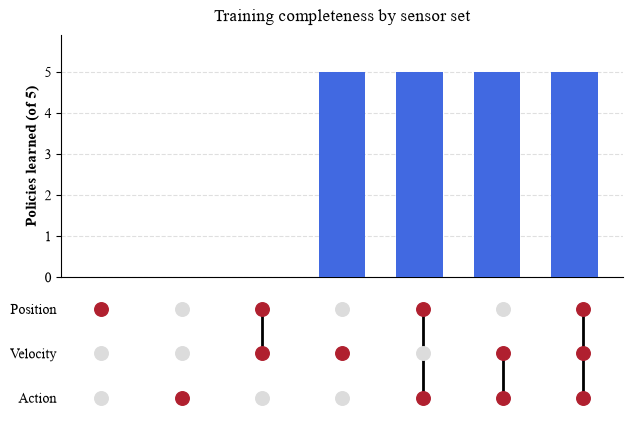

In [14]:
from matplotlib.gridspec import GridSpec

# Canonical sensor order + display names. Only the sensors that actually appear in
# the dict keys become matrix rows, so this adapts if IMU / Foot Contact sets are
# added later.
SENSOR_ORDER = ['pos', 'vel', 'action', 'imu', 'fc']
SENSOR_LABEL = {'pos': 'Position', 'vel': 'Velocity', 'action': 'Action',
                'imu': 'IMU', 'fc': 'Foot Contact'}
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

def upset_plot(data, complete=None, title="Training completeness by sensor set",
               ylabel=None):
    """UpSet-style plot: bar = dict value, dot matrix = active sensors.

    data     : {"pos, vel": value, ...}  (sensor tokens joined by commas)
    complete : value that counts as 'complete' (blue); defaults to max(values).
    """
    parse = lambda k: {s.strip() for s in k.split(',')}
    items = sorted(data.items(), key=lambda kv: (kv[1], len(parse(kv[0]))))
    values = [v for _, v in items]
    sets = [parse(k) for k, _ in items]
    n = len(items)
    vmax = max(values) if values else 1
    complete = vmax if complete is None else complete
    ylabel = ylabel or f"Policies learned (of {vmax})"

    # matrix rows = sensors present anywhere in the data, in canonical order
    present = set().union(*sets) if sets else set()
    rows = [s for s in SENSOR_ORDER if s in present]
    nr = len(rows)
    x = np.arange(n)

    fig = plt.figure(figsize=(max(6, 0.75 * n + 2), 5))
    gs = GridSpec(2, 1, height_ratios=[3, 0.45 * nr + 0.3], hspace=0.05)
    ax, axm = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    COMPLETE, PARTIAL = '#4169E1', '#9e9e9e'
    ax.bar(x, values, width=0.6, zorder=3,
           color=[COMPLETE if v >= complete else PARTIAL for v in values])
    
    # for xi, v in zip(x, values):
    #     ax.annotate(str(v), (xi, v), xytext=(0, 3), textcoords='offset points',
    #                 ha='center', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_ylim(0, vmax * 1.18)
    ax.grid(True, axis='y', ls='--', alpha=0.4); ax.set_axisbelow(True)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.tick_params(axis='x', length=0); ax.set_xticks([])
    ax.set_title(title, fontsize=12, pad=10)

    ACTIVE, INACTIVE = '#b0202f', '#dcdcdc'
    for r in range(nr):
        axm.axhline(r, color="#ffffff", lw=10, zorder=0)
    for i, s in enumerate(sets):
        for r, sensor in enumerate(rows):
            axm.scatter(x[i], r, s=95, zorder=3,
                        color=ACTIVE if sensor in s else INACTIVE)
        active = [r for r, sensor in enumerate(rows) if sensor in s]
        if len(active) >= 2:
            axm.plot([x[i], x[i]], [min(active), max(active)],
                     color='black', lw=2, zorder=2)
    axm.set_yticks(range(nr))
    axm.set_yticklabels([SENSOR_LABEL[s] for s in rows], fontsize=10)
    axm.set_ylim(nr - 0.5, -0.5)                      # first sensor on top
    axm.set_xlim(-0.5, n - 0.5); axm.set_xticks([])
    axm.tick_params(length=0)
    for sp in axm.spines.values():
        sp.set_visible(False)
    fig.tight_layout()
    return fig


f = upset_plot(sheet3_data)
f.savefig("local_prop_train.png", dpi=300, bbox_inches="tight")
plt.show()
